### Phase 3: Adaptive pricing via contextual bandits

In this phase, the focus shifts from optimal decisions under full information to **learning how to price under uncertainty**. While Phase 2 identified a potential **$92k annual revenue uplift**, that result assumes the demand function is known. In practice, pricing decisions must be made without this knowledge and improved over time through interaction with the market.

From a business perspective, this phase represents the transition from a **theoretical pricing strategy** to a **deployable system**, where a pricing manager and data scientist aim to capture the identified margin in a real-world, data-limited setting.

The problem is modeled as a **contextual bandit**, where at each time step $t$, the agent:
- observes the current market state $X_t$ (e.g., seasonality, competitor price),
- selects a price $p_t$ from a discrete set,
- observes the realized revenue,
- and updates its policy.

The objective is to maximize cumulative revenue over time while learning the demand response.

Formally, the bandit seeks to solve:

$$
\max_{\pi} \; \mathbb{E} \left[ \sum_{t=1}^{T} \text{Revenue}_t \right]
$$

where $\pi$ is the pricing policy mapping context to actions, and revenue is defined as:

$$
\text{Revenue}_t = (p_t - \text{unit\_cost}) \cdot \text{demand}(p_t, X_t) - \text{fixed\_costs}
$$

This setup introduces a fundamental trade-off:
- **Exploration**: testing different prices to learn demand,
- **Exploitation**: leveraging current knowledge to maximize revenue.

Unlike Phase 2, where optimal prices were directly computed, the agent must now **discover that optimal price regions lie at lower values** through sequential experimentation.

This phase evaluates whether an adaptive policy can converge to the optimal pricing strategy and **capture the revenue opportunity identified earlier under realistic learning constraints**.

In [7]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import BanditPolicy, simulate, BanditPolicy, FeatureScaler, LinearThompson, MarketPriors

random.seed(42)
np.random.seed(42)

In [8]:
df = pd.read_csv("data/phase_0.csv", parse_dates=["date"])
df = df[df["realized_demand"] > 0].copy()
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.head()

(90, 7)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue
0,2025-01-01,130.000000,120.000000,0.883538,0.000000,25.000000,1550.000000
1,2025-01-02,151.953024,157.389159,0.987371,0.075045,16.066049,1277.321812
2,2025-01-03,100.000000,156.125793,1.055439,0.013403,50.252716,1810.108637
3,2025-01-04,160.000000,160.000000,1.079156,0.014645,14.924950,1292.494956
4,2025-01-05,100.367206,160.000000,1.055439,-0.087101,47.731892,1726.803097


The simulated dataset is well-suited for the contextual bandit use case because it captures the key structural relationships required for learning pricing policies under uncertainty while remaining realistic in terms of observability. Strong correlations between demand and economically meaningful variables such as relative price, competitor price, and own price—indicate that the environment embeds consistent price-response behavior that the bandit can learn. 

At the same time, the absence of direct access to latent drivers (e.g., seasonality) is effectively mitigated by lagged features, which show meaningful correlation with both demand and market conditions, allowing the model to infer hidden states through temporal dynamics. Additionally, the exploration policy used during data generation ensures sufficient coverage of the action space, including both typical operating regions and occasional extreme scenarios, preventing sparsity and enabling stable feature scaling. Altogether, the dataset provides a balanced combination of signal, variability, and partial observability, making it appropriate for training and evaluating an adaptive pricing policy.

In [9]:
price_grid = np.linspace(70, 160, 50)

priors = MarketPriors()
scaler = FeatureScaler()
agent = LinearThompson(n_features=15, v=3.0)

bandit_policy = BanditPolicy(agent, price_grid, scaler)
df_all = simulate(90, bandit_policy, priors, start_df=df)

print(df_all.shape)
df_all.tail()

(180, 8)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue,reward
175,2025-06-25,90.000000,110.979522,2.373959e-05,0.058766,17.277995,318.339843,5.766256
176,2025-06-26,92.040816,127.445405,8.733307e-06,0.112994,23.421829,550.454524,6.312559
177,2025-06-27,90.000000,103.323725,3.073139e-06,0.054414,14.490934,234.728031,5.462679
178,2025-06-28,95.714286,100.000000,1.034389e-06,0.055865,10.706790,182.385367,5.211590
179,2025-06-29,90.000000,108.887859,3.330300e-07,0.134791,17.810400,334.312011,5.815061


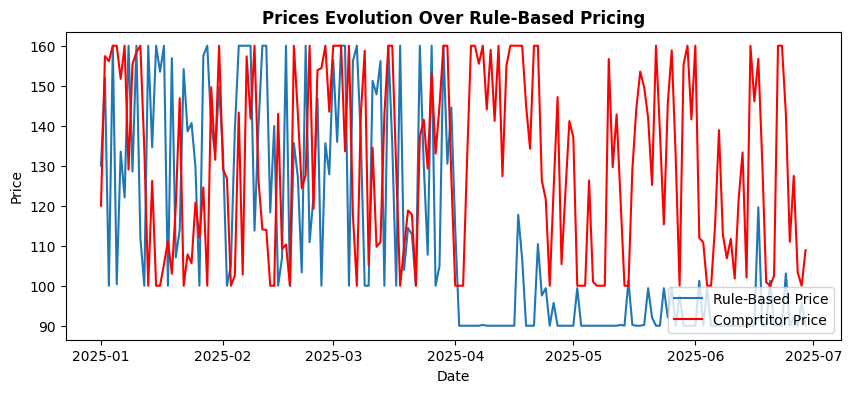

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_all["date"], df_all["price_agent"], label="Rule-Based Price")
plt.plot(df_all["date"], df_all["price_competitor"], label="Comprtitor Price", color="red")

plt.legend(loc="lower right")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.title("Prices Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

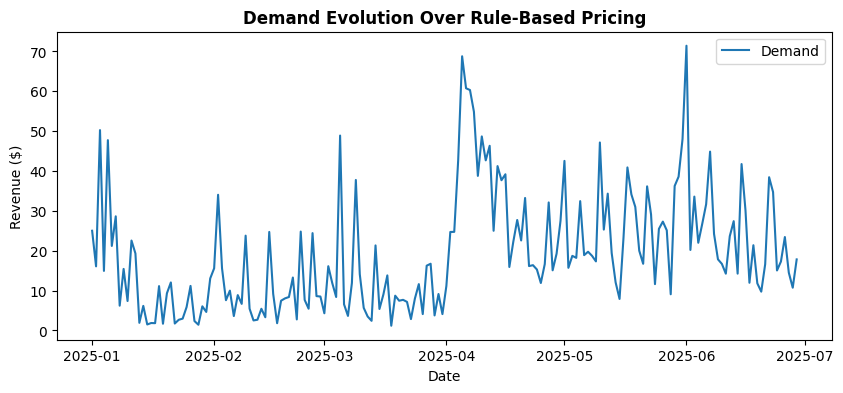

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_all["date"], df_all["realized_demand"], label="Demand")

plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
plt.title("Demand Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

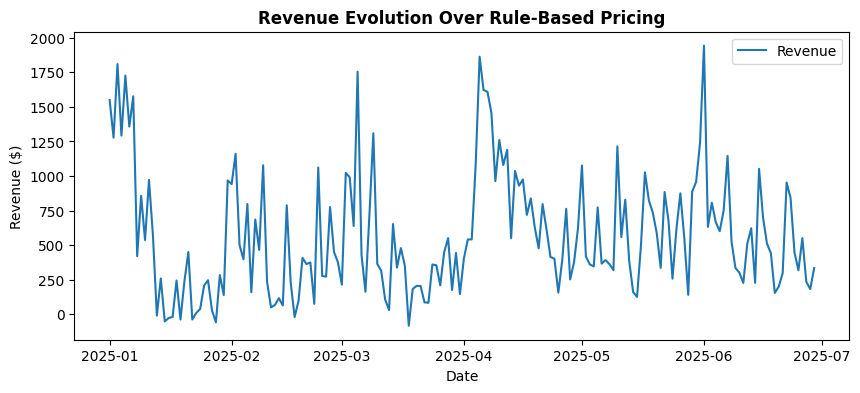

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df_all["date"], df_all["revenue"], label="Revenue")

plt.legend()
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
plt.title("Revenue Evolution Over Rule-Based Pricing", fontweight="bold")
plt.show()

In [21]:
df_old = df_all.iloc[:90]
df_new = df_all.iloc[90:]

total_old = df_old["revenue"].sum()
total_new = df_new["revenue"].sum()

mean_old = df_old["revenue"].mean()
mean_new = df_new["revenue"].mean()

uplift = total_new - total_old
pct_uplift = uplift / total_old

print(
    "total old: $", total_old.round(2),
    "\ntotal new: $", total_new.round(2),
    "\nuplift: $", uplift.round(2),
    "\npct uplift:", pct_uplift.round(3) * 100, "%",
    "\nmean old: $", mean_old.round(2),
    "\nmean new: $", mean_new.round(2),
    "\nmean uplift: $", (mean_new - mean_old).round(2),
)

total old: $ 42316.85 
total new: $ 59857.02 
uplift: $ 17540.17 
pct uplift: 41.4 % 
mean old: $ 470.19 
mean new: $ 665.08 
mean uplift: $ 194.89


In [23]:

total_old = df_old["realized_demand"].sum()
total_new = df_new["realized_demand"].sum()

mean_old = df_old["realized_demand"].mean()
mean_new = df_new["realized_demand"].mean()

uplift = total_new - total_old
pct_uplift = uplift / total_old

print(
    "total old:", total_old.round(2),
    "\ntotal new:", total_new.round(2),
    "\nuplift:", uplift.round(2),
    "\npct uplift:", pct_uplift.round(4) * 100, "%",
    "\nmean old:", mean_old.round(2),
    "\nmean new:", mean_new.round(2),
    "\nmean uplift:", (mean_new - mean_old).round(2),
)

total old: 1006.73 
total new: 2463.78 
uplift: 1457.05 
pct uplift: 144.73 % 
mean old: 11.19 
mean new: 27.38 
mean uplift: 16.19
